Installing needed Libraries

In [1]:
!pip install -U sentence-transformers xgboost scikit-learn pandas matplotlib seaborn imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 588.9/588.9 kB 5.5 MB/s  0:00:00
  Attempting uninstall: sentence-transformers
    Found existing installation: sentence-transformers 5.5.0
    Uninstalling sentence-transformers-5.5.0:
      Successfully uninstalled sentence-transformers-5.5.0


In [2]:
#Importing needed libraries
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

/Users/tsovinarbabakhanyan/Desktop/Armenian Chat part/rag_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
W0524 16:29:08.142000 79902 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [3]:
# 1. LOAD
df = pd.read_csv('/Users/tsovinarbabakhanyan/Desktop/Armenian Chat part/src/data/legal_analysis_labeled.csv').dropna(subset=['Verdict_Text', 'Decision_Label'])

In [14]:
# 2. EMBED + PCA (Reduce 768 -> 20 dimensions)
model = SentenceTransformer('all-mpnet-base-v2')
embeddings = model.encode(df['Verdict_Text'].tolist(), show_progress_bar=True)
pca = PCA(n_components=20, random_state=42)
X = pca.fit_transform(embeddings)

le = LabelEncoder()
y = le.fit_transform(df['Decision_Label'])

# 3. XGBOOST (Tuned for Tiny Data)
clf = XGBClassifier(
    n_estimators=50,
    max_depth=3,          # Keep it shallow so it doesn't memorize
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1,   # Balanced approach
    objective='multi:softprob'
)

# 4. CROSS-VAL
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
all_preds = np.zeros(len(y))

for train_idx, val_idx in skf.split(X, y):
    clf.fit(X[train_idx], y[train_idx])
    all_preds[val_idx] = clf.predict(X[val_idx])

print(f"XGBoost Accuracy: {accuracy_score(y, all_preds)*100:.2f}%")
print(classification_report(y, all_preds, target_names=le.classes_))

Batches: 100%|██████████| 65/65 [15:41<00:00, 14.49s/it]
/Users/tsovinarbabakhanyan/Desktop/Armenian Chat part/rag_env/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [19:50:38] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 68.55%
                              precision    recall  f1-score   support

                    Approved       0.71      0.54      0.61       847
 Partially Approved / Closed       0.67      0.86      0.76      1109
                    Rejected       0.73      0.07      0.13       110
Unknown / Needs Manual Check       0.00      0.00      0.00         7

                    accuracy                           0.69      2073
                   macro avg       0.53      0.37      0.38      2073
                weighted avg       0.69      0.69      0.66      2073



/Users/tsovinarbabakhanyan/Desktop/Armenian Chat part/rag_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/tsovinarbabakhanyan/Desktop/Armenian Chat part/rag_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/tsovinarbabakhanyan/Desktop/Armenian Chat part/rag_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divisio

In [15]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score   
rf_clf = RandomForestClassifier(n_estimators=150, max_depth=10, random_state=42)
rf_clf.fit(X, y)
rf_preds = rf_clf.predict(X)
print(f"Random Forest Accuracy: {accuracy_score(y, rf_preds)*100:.2f}%")
print(classification_report(y, rf_preds, target_names=le.classes_)) 


Random Forest Accuracy: 93.44%
                              precision    recall  f1-score   support

                    Approved       0.97      0.94      0.95       847
 Partially Approved / Closed       0.91      1.00      0.95      1109
                    Rejected       1.00      0.32      0.48       110
Unknown / Needs Manual Check       1.00      0.14      0.25         7

                    accuracy                           0.93      2073
                   macro avg       0.97      0.60      0.66      2073
                weighted avg       0.94      0.93      0.92      2073



In [16]:
#Desison Tree
from sklearn.tree import DecisionTreeClassifier
dt_clf = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_clf.fit(X, y)
dt_preds = dt_clf.predict(X)
print(f"Decision Tree Accuracy: {accuracy_score(y, dt_preds)*100:.2f}%")
print(classification_report(y, dt_preds, target_names=le.classes_))

Decision Tree Accuracy: 61.94%
                              precision    recall  f1-score   support

                    Approved       0.60      0.47      0.53       847
 Partially Approved / Closed       0.63      0.79      0.70      1109
                    Rejected       1.00      0.03      0.05       110
Unknown / Needs Manual Check       0.00      0.00      0.00         7

                    accuracy                           0.62      2073
                   macro avg       0.56      0.32      0.32      2073
                weighted avg       0.63      0.62      0.59      2073



/Users/tsovinarbabakhanyan/Desktop/Armenian Chat part/rag_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/tsovinarbabakhanyan/Desktop/Armenian Chat part/rag_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/tsovinarbabakhanyan/Desktop/Armenian Chat part/rag_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divisio

In [17]:
#SVM
from sklearn.svm import SVC
svm_clf = SVC(kernel='linear', random_state=42)
svm_clf.fit(X, y)
svm_preds = svm_clf.predict(X)
print(f"SVM Accuracy: {accuracy_score(y, svm_preds)*100:.2f}%")
print(classification_report(y, svm_preds, target_names=le.classes_))

SVM Accuracy: 53.50%
                              precision    recall  f1-score   support

                    Approved       0.00      0.00      0.00       847
 Partially Approved / Closed       0.53      1.00      0.70      1109
                    Rejected       0.00      0.00      0.00       110
Unknown / Needs Manual Check       0.00      0.00      0.00         7

                    accuracy                           0.53      2073
                   macro avg       0.13      0.25      0.17      2073
                weighted avg       0.29      0.53      0.37      2073



/Users/tsovinarbabakhanyan/Desktop/Armenian Chat part/rag_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/tsovinarbabakhanyan/Desktop/Armenian Chat part/rag_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/tsovinarbabakhanyan/Desktop/Armenian Chat part/rag_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divisio

In [20]:
#Naive Bayes
from sklearn.naive_bayes import GaussianNB
nb_clf = GaussianNB()
nb_clf.fit(X, y)
nb_preds = nb_clf.predict(X)
print(f"Naive Bayes Accuracy: {accuracy_score(y, nb_preds)*100:.2f}%")
print(classification_report(y, nb_preds, target_names=le.classes_))

Naive Bayes Accuracy: 58.47%
                              precision    recall  f1-score   support

                    Approved       0.54      0.48      0.51       847
 Partially Approved / Closed       0.61      0.72      0.66      1109
                    Rejected       0.35      0.05      0.09       110
Unknown / Needs Manual Check       0.50      0.43      0.46         7

                    accuracy                           0.58      2073
                   macro avg       0.50      0.42      0.43      2073
                weighted avg       0.57      0.58      0.57      2073



In [21]:
#KNN
from sklearn.neighbors import KNeighborsClassifier
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X, y)
knn_preds = knn_clf.predict(X)
print(f"KNN Accuracy: {accuracy_score(y, knn_preds)*100:.2f}%")
print(classification_report(y, knn_preds, target_names=le.classes_))    

KNN Accuracy: 78.49%
                              precision    recall  f1-score   support

                    Approved       0.76      0.77      0.77       847
 Partially Approved / Closed       0.81      0.85      0.83      1109
                    Rejected       0.73      0.29      0.42       110
Unknown / Needs Manual Check       0.00      0.00      0.00         7

                    accuracy                           0.78      2073
                   macro avg       0.57      0.48      0.50      2073
                weighted avg       0.78      0.78      0.78      2073



Python(83507) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
/Users/tsovinarbabakhanyan/Desktop/Armenian Chat part/rag_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/tsovinarbabakhanyan/Desktop/Armenian Chat part/rag_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/tsovinarbabakhanyan/Desktop/Armenian Chat part/rag_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Pr

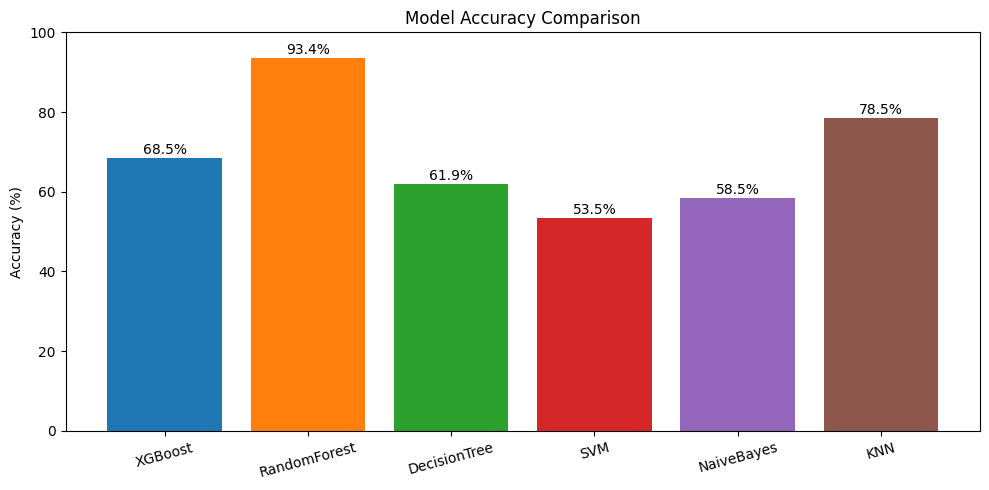

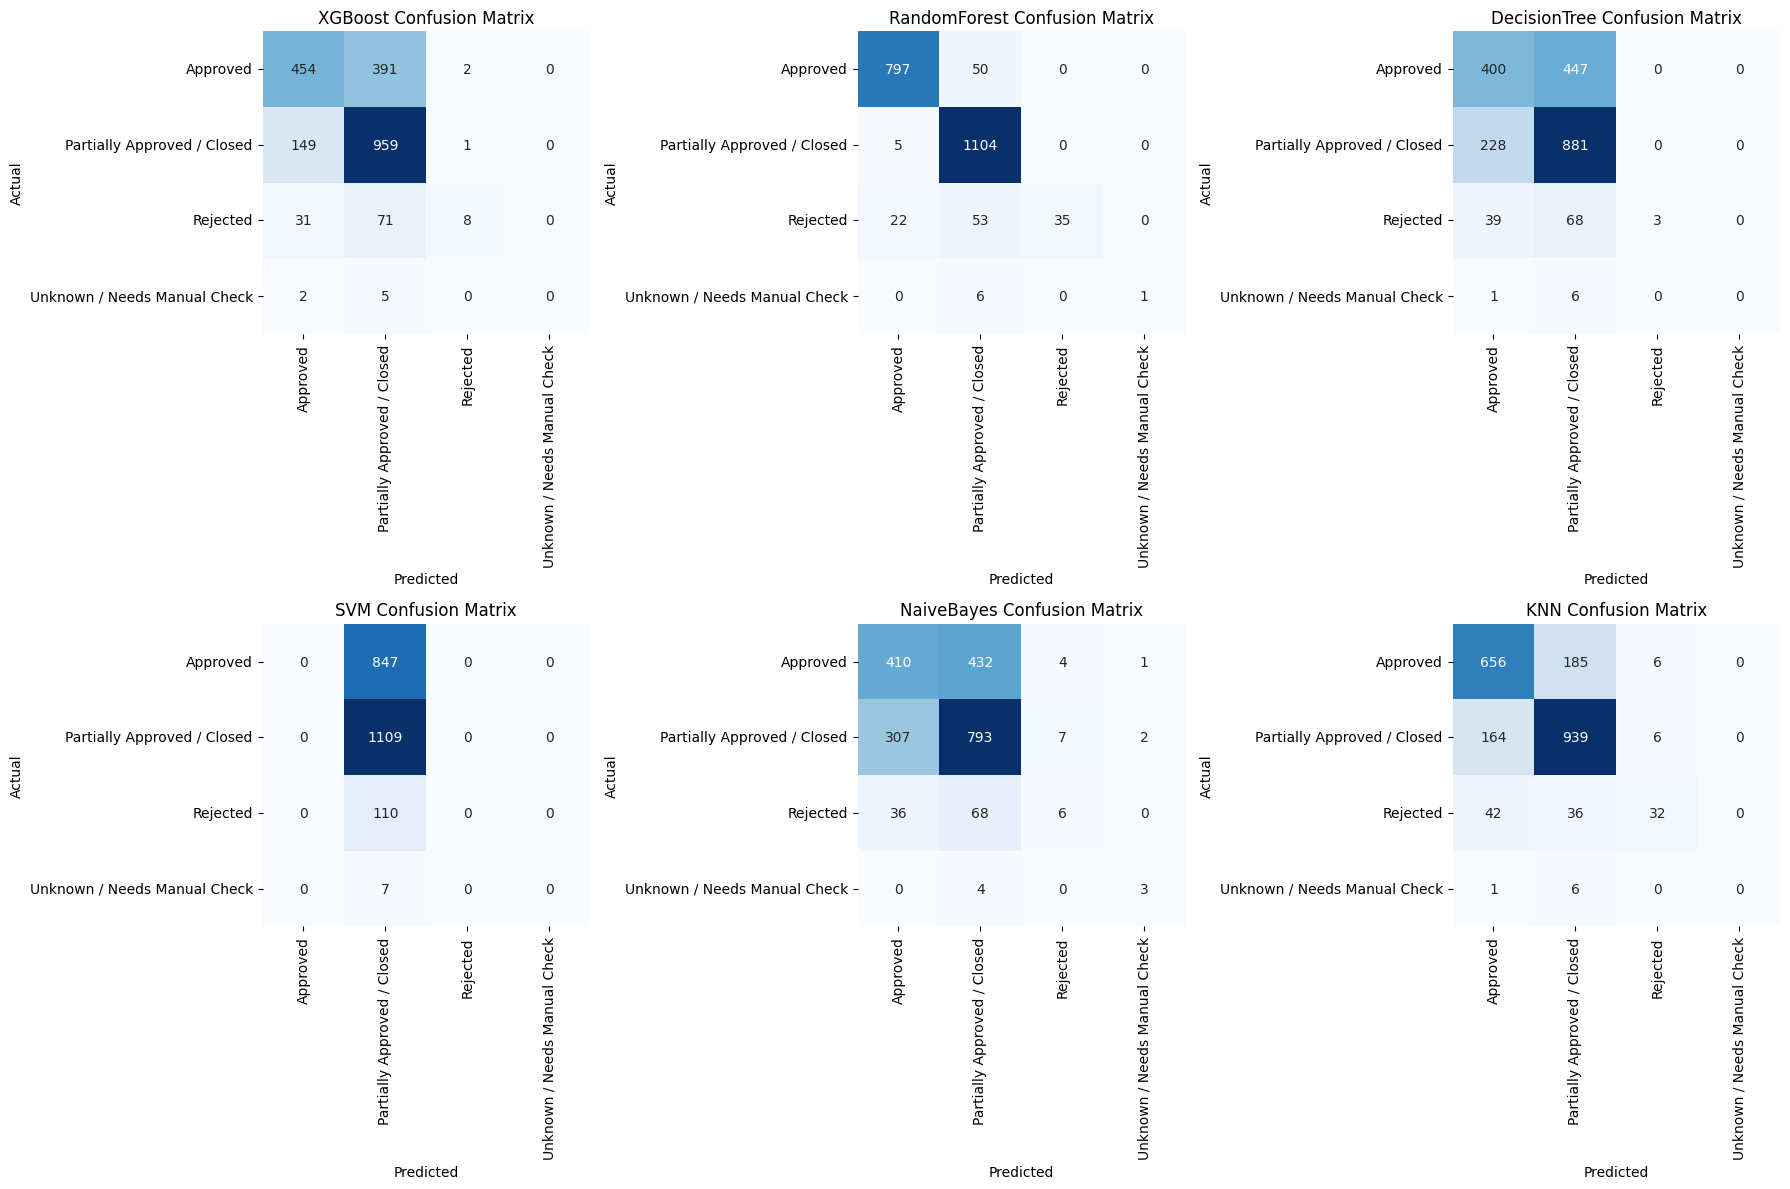

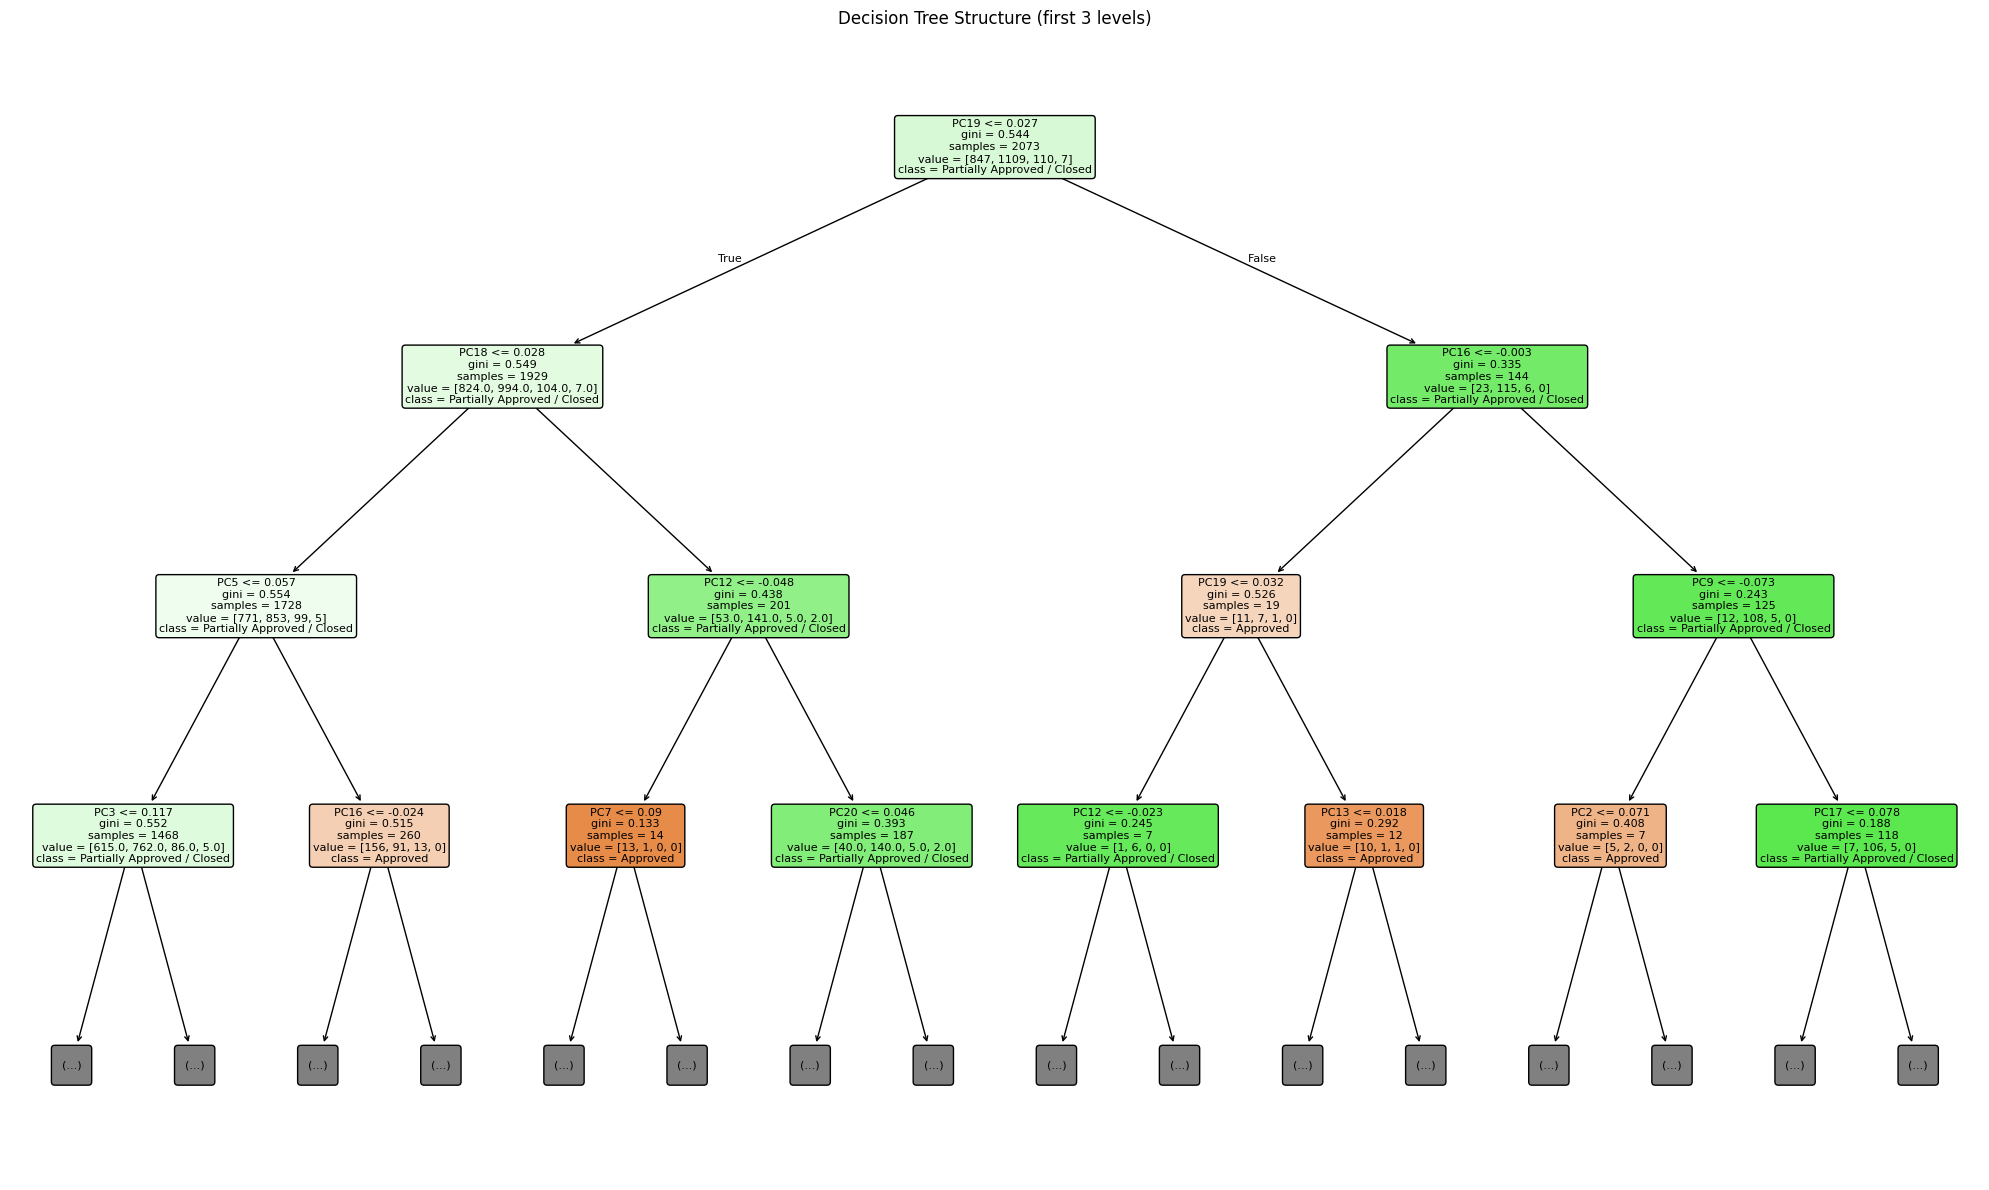

In [22]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn import tree

import matplotlib.pyplot as plt

model_preds = {
    "XGBoost": all_preds,
    "RandomForest": rf_preds,
    "DecisionTree": dt_preds,
    "SVM": svm_preds,
    "NaiveBayes": nb_preds,
    "KNN": knn_preds,
}

accuracies = {name: accuracy_score(y, preds) for name, preds in model_preds.items()}

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(accuracies.keys(), [val * 100 for val in accuracies.values()], color=sns.color_palette("tab10", len(accuracies)))
ax.set_ylabel("Accuracy (%)")
ax.set_title("Model Accuracy Comparison")
ax.set_ylim(0, 100)
for bar, val in zip(bars, accuracies.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, f"{val*100:.1f}%", ha="center")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for ax, (name, preds) in zip(axes.flatten(), model_preds.items()):
    cm = confusion_matrix(y, preds, labels=np.unique(y))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        xticklabels=le.classes_,
        yticklabels=le.classes_,
        cbar=False,
    )
    ax.set_title(f"{name} Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

plt.figure(figsize=(20, 12))
tree.plot_tree(
    dt_clf,
    feature_names=[f"PC{i+1}" for i in range(X.shape[1])],
    class_names=le.classes_,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8,
)
plt.title("Decision Tree Structure (first 3 levels)")
plt.tight_layout()
plt.show()

In [23]:
import json

# Assuming report_df and report_dict are already created from the classification report
report_dict = classification_report(y, all_preds, target_names=le.classes_, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
report_df.to_csv('/Users/tsovinarbabakhanyan/Desktop/Armenian Chat part/src/data/classification_report.csv', index=True)

with open('/Users/tsovinarbabakhanyan/Desktop/Armenian Chat part/src/data/classification_report.json', 'w', encoding='utf-8') as f:
    json.dump(report_dict, f, indent=2, ensure_ascii=False)

print("Saved report_df to classification_report.csv and report_dict to classification_report.json")

Saved report_df to classification_report.csv and report_dict to classification_report.json


/Users/tsovinarbabakhanyan/Desktop/Armenian Chat part/rag_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/tsovinarbabakhanyan/Desktop/Armenian Chat part/rag_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/tsovinarbabakhanyan/Desktop/Armenian Chat part/rag_env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_divisio